# Baseline Model - Logistic Regression

This notebook trains a Logistic Regression baseline model for multiclass flight delay classification.

The goal is to establish an initial performance reference before comparing with ensemble models such as LightGBM and CatBoost.

In [29]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

## Load Dataset

The dataset used in this notebook was already prepared and contains the initial feature engineering step.

In [30]:
data= pd.read_csv("/Users/Cliscia-Aula/Downloads/flight_delay_training.csv")

data.head()

,airline_icao,origin_icao,destination_icao,route,year,month,day,weekday,hour,period,delayed_15_min_plus
0,TAM,SBRJ,SBGR,SBRJ_SBGR,2022,1,6,3,14,afternoon,False
1,TAM,SBRJ,SBGR,SBRJ_SBGR,2022,1,7,4,14,afternoon,True
2,TAM,SBRJ,SBGR,SBRJ_SBGR,2022,1,8,5,14,afternoon,False
3,TAM,SBRJ,SBGR,SBRJ_SBGR,2022,1,9,6,14,afternoon,False
4,TAM,SBRJ,SBGR,SBRJ_SBGR,2022,1,11,1,14,afternoon,False


In [31]:
data.shape

(2983940, 11)

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2983940 entries, 0 to 2983939
Data columns (total 11 columns):
 #   Column               Dtype
---  ------               -----
 0   airline_icao         str  
 1   origin_icao          str  
 2   destination_icao     str  
 3   route                str  
 4   year                 int64
 5   month                int64
 6   day                  int64
 7   weekday              int64
 8   hour                 int64
 9   period               str  
 10  delayed_15_min_plus  bool 
dtypes: bool(1), int64(5), str(5)
memory usage: 230.5 MB


In [34]:
# Features
X = data.drop(
    columns=[
        "delayed_15_min_plus",
        "year",
        "day",
        "route"]
)

# Target
y = data["delayed_15_min_plus"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2983940, 7)
Target shape: (2983940,)


In [36]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2387152, 7)
X_test: (596788, 7)
y_train: (2387152,)
y_test: (596788,)


## Feature Preprocessing

Prepare categorical and numerical features for Logistic Regression.


In [38]:
# Categorical features
categorical_features = [
    "airline_icao",
    "origin_icao",
    "destination_icao",
    "period"
]

# Numerical features
numerical_features = [
    "month",
    "weekday",
    "hour"
]

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

## Logistic Regression Baseline

Train a baseline Logistic Regression model using the preprocessing pipeline.

In [63]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [64]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['airline_icao','origin_icao','destination_icao',...,'weekday','hour', 'period']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

## Predictions

Generate predictions and predicted probabilities on the test set.

In [65]:
# Predicted classes
y_pred = model.predict(X_test)

# Predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

In [66]:
y_proba[:20]

array([0.12851237, 0.12559128, 0.13762465, 0.1345284 , 0.13149119,
       0.12851237, 0.12559128, 0.13762465, 0.1345284 , 0.13944259,
       0.13631191, 0.13324063, 0.13022812, 0.12727372, 0.12437677,
       0.12153656, 0.13944259, 0.13631191, 0.13324063, 0.13022812])

In [76]:
accuracy_default = accuracy_score(y_test, y_pred)
precision_default = precision_score(y_test, y_pred)
recall_default = recall_score(y_test, y_pred)
f1_default = f1_score(y_test, y_pred)
roc_auc_default = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.5245
Precision: 0.1845
Recall   : 0.6359
F1-score : 0.2860
ROC-AUC  : 0.6003


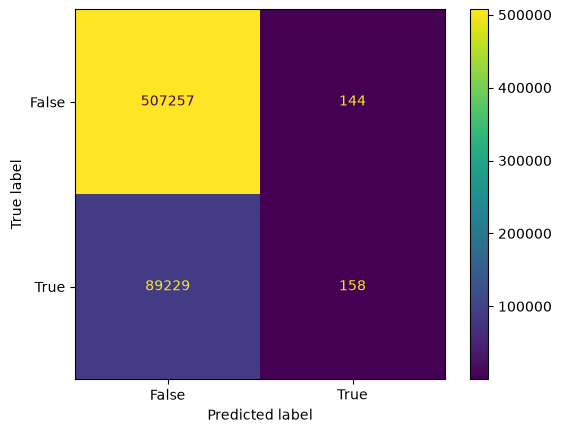

In [77]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.85      1.00      0.92    507401
        True       0.52      0.00      0.00     89387

    accuracy                           0.85    596788
   macro avg       0.69      0.50      0.46    596788
weighted avg       0.80      0.85      0.78    596788



## Logistic Regression (Balanced)

Since the target is imbalanced, class weights are introduced to improve sensitivity to delayed flights.

In [79]:
model_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         max_iter=1000,
         random_state=42,
         class_weight="balanced"
     ))
])

model_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['airline_icao','origin_icao','destination_icao',...,'weekday','hour', 'period']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [80]:
y_pred_balanced = model_balanced.predict(X_test)
y_proba_balanced = model_balanced.predict_proba(X_test)[:,1]

In [82]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_proba_balanced)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.5245
Precision: 0.1845
Recall   : 0.6359
F1-score : 0.2860
ROC-AUC  : 0.6003


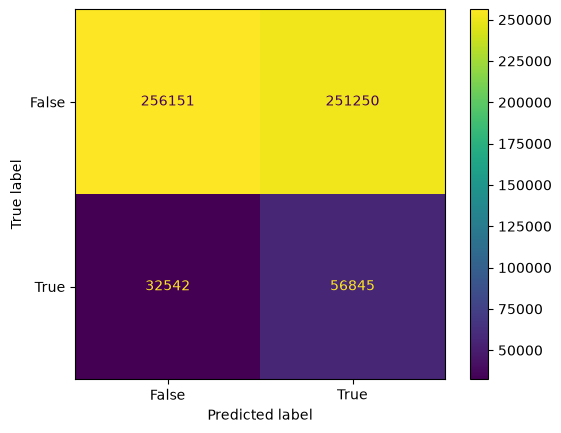

In [83]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced
)

In [84]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)"
    ],
    "Accuracy": [
        accuracy_default,
        accuracy_balanced
    ],
    "Precision": [
        precision_default,
        precision_balanced
    ],
    "Recall": [
        recall_default,
        recall_balanced
    ],
    "F1-score": [
        f1_default,
        f1_balanced
    ],
    "ROC-AUC": [
        roc_auc_default,
        roc_auc_balanced
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.850243,0.523179,0.001768,0.003523,0.600446
1,Logistic Regression (Balanced),0.524468,0.184505,0.635943,0.286026,0.600321


# Conclusions

Two baseline models were evaluated:

1. Logistic Regression
2. Logistic Regression with class balancing

The balanced version achieved a significantly higher recall and F1-score, while maintaining a similar ROC-AUC.

This baseline will serve as a reference for future feature engineering experiments and more advanced models such as LightGBM and CatBoost.